<img src=img/itq.jpg>

![logo](img/python.jpg)

Geovanny Nazareno

## Examen Practico - Segundo Parcial

#### 0) Cargar una de las imágenes histológicas

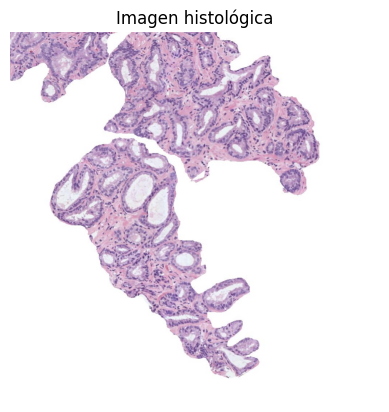

In [1]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
imagen = io.imread('exm/histo_2.jpg')
imagen = imagen / 255.0

# Visualizar la imagen
plt.imshow(imagen)
plt.title("Imagen histológica")
plt.axis('off')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

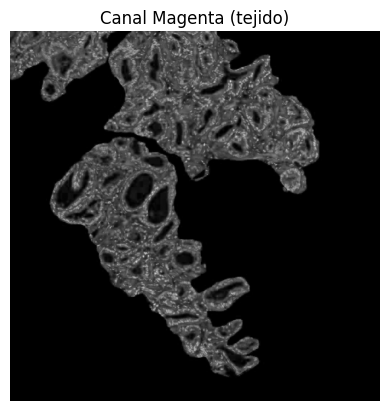

In [2]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
R = imagen[:, :, 0]
G = imagen[:, :, 1]
B = imagen[:, :, 2]

C = 1 - R
M = 1 - G
Y = 1 - B

K = np.minimum(np.minimum(C, M), Y)

C = (C - K) / (1 - K + 1e-8)
M = (M - K) / (1 - K + 1e-8)
Y = (Y - K) / (1 - K + 1e-8)

# Visualizar la imagen del canal magenta
canal_magenta = M
plt.imshow(canal_magenta, cmap='gray')
plt.title("Canal Magenta (tejido)")
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

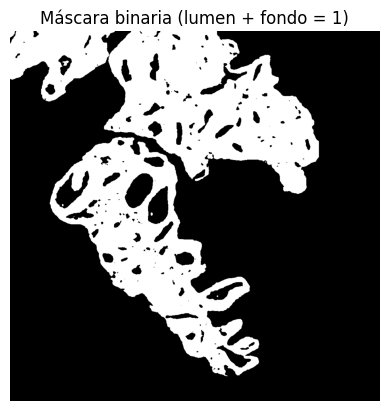

In [3]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
from skimage import filters
import cv2
#Convertir el canal magenta a rango [0-255] y tipo uint8
magenta_uint8 = (canal_magenta * 255).astype(np.uint8)
# Aplicar filtro Gaussiano (5x5)
blur = cv2.GaussianBlur(magenta_uint8, (5, 5), 0)
# Aplicar método de Otsu
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Convertir a máscara binaria (0 y 1)
mascara = (otsu == 255).astype(np.uint8)

# Visualizar la máscara resultante
plt.imshow(mascara, cmap='gray')
plt.title("Máscara binaria (lumen + fondo = 1)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\HP\AppData\Local\Temp\ipykernel_15560\368538090.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_limpia = remove_small_objects(mascara_bool, min_size=300)


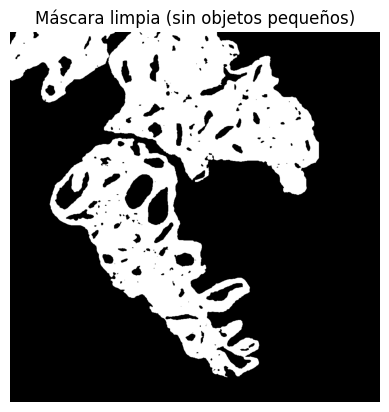

In [4]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
from skimage.morphology import remove_small_objects

# Convertir la máscara a tipo booleano
mascara_bool = mascara.astype(bool)
# Eliminar objetos pequeños (< 300 píxeles)
mascara_limpia = remove_small_objects(mascara_bool, min_size=300)
#Convertir de nuevo a 0 y 1
mascara_limpia = mascara_limpia.astype(np.uint8)

# Visualizaer la máscara resultante
plt.imshow(mascara_limpia, cmap='gray')
plt.title("Máscara limpia (sin objetos pequeños)")
plt.axis('off')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

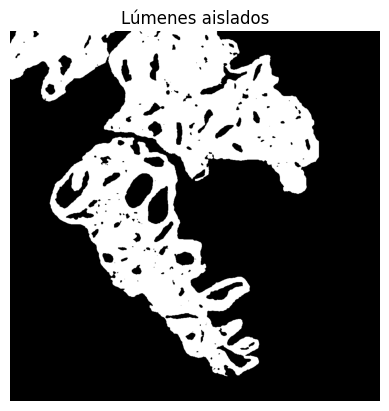

In [5]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
from skimage.segmentation import flood

#Usamos la máscara limpia
mascara_rg = mascara_limpia.copy()
# Obtener dimensiones
h, w = mascara_rg.shape
# Crear máscara de fondo (region growing)
fondo = np.zeros_like(mascara_rg, dtype=bool)
# Semillas automáticas
semillas = [(0,0), (0,w-1), (h-1,0), (h-1,w-1)]

for semilla in semillas:
    region = flood(mascara_rg, seed_point=semilla, tolerance=0)
    fondo = fondo | region

# Eliminar el fondo
lumenes = mascara_rg.copy()
lumenes[fondo] = 0

# Visualizar la máscara resultante. 
plt.imshow(lumenes, cmap='gray')
plt.title("Lúmenes aislados")
plt.axis('off')
plt.show()

#### 5) Rellenar los objetos de los lúmenes

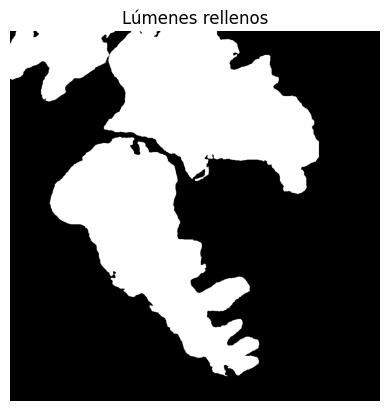

In [6]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
from scipy.ndimage import binary_fill_holes

# Rellenar los huecos dentro de los lúmenes
lumenes_rellenos = binary_fill_holes(lumenes)
# Convertir a formato 0 y 1
lumenes_rellenos = lumenes_rellenos.astype(np.uint8)

# Visualizar la máscara resultante
plt.imshow(lumenes_rellenos, cmap='gray')
plt.title("Lúmenes rellenos")
plt.axis('off')
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

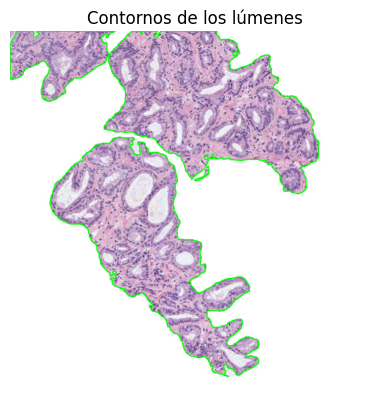

In [7]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Convertir máscara a uint8 (0-255)
mask_uint8 = (lumenes_rellenos * 255).astype(np.uint8)

# Encontrar contornos
contornos, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Copiar imagen original (en RGB)
imagen_contornos = (imagen * 255).astype(np.uint8).copy()
# Dibujar contornos en verde
cv2.drawContours(imagen_contornos, contornos, -1, (0,255,0), 2)

# Visualizar la imagen superpuesta
plt.imshow(imagen_contornos)
plt.title("Contornos de los lúmenes")
plt.axis('off')
plt.show()

#### 7) Identificar y cropear el lumen más grande

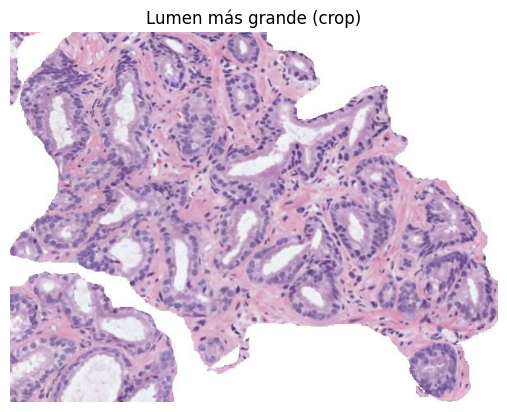

In [8]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Encontrar el contorno con mayor área
area_max = 0
contorno_max = None

for cnt in contornos:
    area = cv2.contourArea(cnt)
    if area > area_max:
        area_max = area
        contorno_max = cnt

# Obtener bounding box del mayor lumen
x, y, w, h = cv2.boundingRect(contorno_max)
# Cropear desde la imagen original
imagen_uint8 = (imagen * 255).astype(np.uint8)
lumen_crop = imagen_uint8[y:y+h, x:x+w]

# Visualizar el lumen cropeado.
plt.imshow(lumen_crop)
plt.title("Lumen más grande (crop)")
plt.axis('off')
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [10]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

from skimage.measure import regionprops, label
from scipy.spatial.distance import pdist

# Etiquetar la máscara de lúmenes
labels = label(lumenes_rellenos)

# Obtener propiedades de las regiones
props = regionprops(labels)

# Buscar la región con mayor área
region_max = max(props, key=lambda x: x.area)

# 1) Área
area = round(region_max.area, 4)

# 2) Área bounding box
minr, minc, maxr, maxc = region_max.bbox
area_bbox = round((maxr - minr) * (maxc - minc), 4)

# 3) Área convexa
area_convexa = round(region_max.convex_area, 4)

# 4) Excentricidad
excentricidad = round(region_max.eccentricity, 4)

# 5) Diámetro equivalente
diam_eq = round(region_max.equivalent_diameter, 4)

# 6) Extensión
extension = round(region_max.extent, 4)

# 7) Diámetro de Feret (máxima distancia entre puntos del contorno)
minr, minc, maxr, maxc = region_max.bbox
feret = round(np.sqrt((maxr - minr)**2 + (maxc - minc)**2), 4)

# 8) Longitud eje mayor
eje_mayor = round(region_max.major_axis_length, 4)

# 9) Longitud eje menor
eje_menor = round(region_max.minor_axis_length, 4)

# 10) Orientación
orientacion = round(region_max.orientation, 4)

# 11) Perímetro
perimetro = round(region_max.perimeter, 4)

# 12) Solidez
solidez = round(region_max.solidity, 4)

# 13) Compacidad (circularidad)
compacidad = round((4 * np.pi * area) / (perimetro ** 2), 4) if perimetro != 0 else 0

# Mostrar resultados
print("1) Área:", area)
print("2) Área bounding box:", area_bbox)
print("3) Área convexa:", area_convexa)
print("4) Excentricidad:", excentricidad)
print("5) Diámetro equivalente:", diam_eq)
print("6) Extensión:", extension)
print("7) Diámetro Feret:", feret)
print("8) Eje mayor:", eje_mayor)
print("9) Eje menor:", eje_menor)
print("10) Orientación:", orientacion)
print("11) Perímetro:", perimetro)
print("12) Solidez:", solidez)
print("13) Compacidad:", compacidad)

1) Área: 164089.0
2) Área bounding box: 268345
3) Área convexa: 202123.0
4) Excentricidad: 0.8377
5) Diámetro equivalente: 457.0827
6) Extensión: 0.6115
7) Diámetro Feret: 746.6097
8) Eje mayor: 639.1888
9) Eje menor: 349.0928
10) Orientación: 1.1232
11) Perímetro: 2456.4175
12) Solidez: 0.8118
13) Compacidad: 0.3417


C:\Users\HP\AppData\Local\Temp\ipykernel_15560\3451478516.py:36: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  area_convexa = round(region_max.convex_area, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_15560\3451478516.py:42: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  diam_eq = round(region_max.equivalent_diameter, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_15560\3451478516.py:52: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  eje_mayor = round(region_max.major_axis_length, 4)
C:\Users\HP\AppData\Local\Temp\ipykernel_15560\3451478516.py:55: FutureWarning: `RegionProperties.minor_axis_length` i

https://github.com/GeovanyNazareno/maching2026.git